## Step 1: Imports and Setup
Load core Python, geospatial, stats, and plotting libraries used throughout the notebook.


In [1]:
import re
import subprocess
import sys
from pathlib import Path

# Source data locations
DATA_311_URL = "https://drive.google.com/file/d/1m3Wg1q7v6IZqqDL8SR6R2luZ113D_eOF/view?usp=drive_link"
ASSEMBLY_FOLDER_URL = "https://drive.google.com/drive/folders/1noTeCorGZyfGa7Gc9sCCFp5jcd12R6YO?usp=drive_link"

base_dir = Path("hackathon_data") if Path("hackathon_data").exists() else Path(".")
out_path = base_dir / "311_data.gpkg"
assembly_dir = base_dir / "reference_data" / "assembly_districts"

def ensure_pkg(import_name, *pip_names):
    try:
        __import__(import_name)
    except ImportError:
        pkgs = list(pip_names) if pip_names else [import_name]
        subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs])

ensure_pkg("gdown")
ensure_pkg("geopandas", "geopandas", "pyogrio")

import gdown
import geopandas as gpd
import pandas as pd

match = re.search(r"/d/([A-Za-z0-9_-]+)", DATA_311_URL)
if not match:
    raise ValueError("Could not parse Google Drive file ID from URL")
file_id = match.group(1)

if not out_path.exists():
    gdown.download(id=file_id, output=str(out_path), quiet=False, fuzzy=True)
else:
    print(f"Using existing file: {out_path}")

def find_geofile(root: Path):
    patterns = ["*.gpkg", "*.geojson", "*.json", "*.shp"]
    for pattern in patterns:
        files = sorted(root.rglob(pattern))
        if files:
            return files[0]
    zip_files = sorted(root.rglob("*.zip"))
    if zip_files:
        return zip_files[0]
    return None

def download_assembly_district_data(folder_url: str, target_dir: Path) -> Path:
    target_dir.mkdir(parents=True, exist_ok=True)
    geofile = find_geofile(target_dir)
    if geofile is None:
        print(f"Downloading Assembly District data to: {target_dir}")
        gdown.download_folder(url=folder_url, output=str(target_dir), quiet=False, remaining_ok=True)
        geofile = find_geofile(target_dir)
    if geofile is None:
        raise FileNotFoundError(
            f"No geospatial file found in {target_dir}. Confirm the Drive folder contains a GPKG, SHP, GeoJSON, or zipped shapefile."
        )
    return geofile

def read_geofile(path: Path):
    if path.suffix.lower() == ".zip":
        return gpd.read_file(f"zip://{path}")
    try:
        return gpd.read_file(path, engine="pyogrio")
    except Exception:
        return gpd.read_file(path)

def attach_assembly_districts(points_gdf: gpd.GeoDataFrame, districts_gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    out = points_gdf.copy()
    if out.empty or "geometry" not in out.columns:
        out["assembly_district"] = pd.NA
        return out

    candidates = [
        c for c in districts_gdf.columns
        if c != "geometry" and any(k in c.lower() for k in ["district", "assembly", "name", "number", "ad"]) 
    ]
    district_col = candidates[0] if candidates else None
    if district_col is None:
        districts = districts_gdf[["geometry"]].copy()
        districts["assembly_district"] = (districts.index + 1).astype(str)
    else:
        districts = districts_gdf[[district_col, "geometry"]].rename(columns={district_col: "assembly_district"}).copy()

    points_valid = out.loc[out.geometry.notna()].copy()
    if points_valid.empty:
        out["assembly_district"] = pd.NA
        return out

    if points_valid.crs is None:
        points_valid = points_valid.set_crs("EPSG:4326")
    if districts.crs is None:
        districts = districts.set_crs(points_valid.crs)
    else:
        districts = districts.to_crs(points_valid.crs)

    joined = gpd.sjoin(
        points_valid,
        districts[["assembly_district", "geometry"]],
        how="left",
        predicate="intersects",
    )

    out["assembly_district"] = pd.NA
    out.loc[joined.index, "assembly_district"] = joined["assembly_district"].astype("string")
    return out

try:
    gdf = gpd.read_file(out_path, engine="pyogrio")
except Exception:
    gdf = gpd.read_file(out_path)

assembly_data_path = download_assembly_district_data(ASSEMBLY_FOLDER_URL, assembly_dir)
assembly_districts_gdf = read_geofile(assembly_data_path)
gdf = attach_assembly_districts(gdf, assembly_districts_gdf)

print(f"Loaded {len(gdf):,} rows from {out_path}")
print(f"Assembly districts source: {assembly_data_path}")
print("assembly_district null rows:", int(gdf["assembly_district"].isna().sum()))
gdf.head()



Using existing file: hackathon_data\311_data.gpkg


C:\Users\Scott.Coffin\AppData\Roaming\Python\Python314\site-packages\pyogrio\raw.py:200: RuntimeWarning: Non-conformant content for record 1 in column DateCreated, 2020-04-15T18:21:00.0Z, successfully parsed
  return ogr_read(


Loaded 1,545,157 rows from hackathon_data\311_data.gpkg
Assembly districts source: hackathon_data\reference_data\assembly_districts\Council_Districts.shp
assembly_district null rows: 377912


,ReferenceNumber,CategoryLevel1,CategoryLevel2,CategoryName,CouncilDistrictNumber,SourceLevel1,Neighborhood,DateCreated,DateUpdated,DateClosed,CrossStreet,GlobalID,ZIP,SFTicketID,Address,Data_Source,PublicStatus,geometry,assembly_district
0,200415-002042,Homeless Camp,Concern,Homeless Camp Concern,District 1,Phone,None,2020-04-15 18:21:00+00:00,2024-06-21 18:22:00+00:00,2024-06-21 18:22:00+00:00,SOTNIP RD,{CA1309DA-F18B-4EFF-A700-DAC37C7D899A},95835,5001U00000YnTdzQAF,"E LEVEE RD & BARROS DR, SACRAMENTO, 95835",311,CLOSED,POINT (-13522810.419 4673496.533),Lisa Kaplan
1,200423-012910,Homeless Camp,Concern,Homeless Camp Concern,District 6,Phone,None,2020-04-23 21:47:00+00:00,2024-02-14 18:27:00+00:00,2024-02-14 18:27:00+00:00,STOCKTON BLVD,{41762711-569B-48EB-BD87-D5B149F50F41},95828,5001U00000YoFdvQAF,"6100 48TH AVE, SACRAMENTO 95828",311,CLOSED,POINT (-13517904.636 4651614.746),Eric Guerra
2,200427-016582,Homeless Camp,Concern,Homeless Camp Concern,District 3,Web,None,2020-04-27 18:06:00+00:00,2024-06-21 18:28:00+00:00,2024-06-21 18:28:00+00:00,A ST,{06769148-A9CA-475C-ACB7-94F14C249D9B},95811,5001U00000YoW0LQAV,"105 N 16TH ST, SACRAMENTO, 95811",311,CLOSED,POINT (-13523175.71 4662835.794),Phil Pluckebaum
3,200428-018256,Facilities,Repair,Facilities Repair,Non City,Phone,None,2020-04-28 18:10:00+00:00,2023-03-10 18:52:00+00:00,2023-03-10 18:52:00+00:00,WALNUT RD,{63863BD9-1F4A-466A-BEF8-5528DF206ED2},95837,5001U00000YocmPQAR,"7208 W ELKHORN BLVD, SACRAMENTO 95837",311,CLOSED,POINT (-13539266.471 4676655.335),<NA>
4,200511-034691,Homeless Camp,Park or Bike Trail,Homeless Camp Park or Bike Trail,District 3,Web,None,2020-05-11 01:56:00+00:00,2024-02-14 19:45:00+00:00,2024-02-14 19:45:00+00:00,N 16TH ST,{0D9DA3B9-BFE2-4B9C-B302-9C3536456FEA},95811,5001U00000apai0QAA,"1630 BASLER ST, SACRAMENTO 95811",311,CLOSED,POINT (-13522734.422 4663265.381),Phil Pluckebaum


## Step 2: Beta Subset Creation
Create a smaller reproducible subset of the source data for quick iteration and testing.


In [2]:
# Create a smaller, reproducible subset for quick beta testing
import pandas as pd

BETA_N = 50000
RANDOM_SEED = 42

if len(gdf) > BETA_N:
    beta_gdf = gdf.sample(n=BETA_N, random_state=RANDOM_SEED).copy()
else:
    beta_gdf = gdf.copy()

beta_gdf = beta_gdf.reset_index(drop=True)

if "DateCreated" in beta_gdf.columns:
    beta_gdf["DateCreated"] = pd.to_datetime(beta_gdf["DateCreated"], errors="coerce", utc=True)

beta_path = out_path.with_name("311_data_beta_50k.gpkg")
beta_gdf.to_file(beta_path, driver="GPKG")

print(f"Beta subset rows: {len(beta_gdf):,}")
print(f"Saved beta subset to: {beta_path}")
beta_gdf.head()


Beta subset rows: 50,000
Saved beta subset to: hackathon_data\311_data_beta_50k.gpkg


,ReferenceNumber,CategoryLevel1,CategoryLevel2,CategoryName,CouncilDistrictNumber,SourceLevel1,Neighborhood,DateCreated,DateUpdated,DateClosed,CrossStreet,GlobalID,ZIP,SFTicketID,Address,Data_Source,PublicStatus,geometry,assembly_district
0,250620-3106855,Parks,General,Parks General,Non City,Phone,None,2025-06-20 07:35:00+00:00,2025-06-20 07:35:00+00:00,2025-06-20 07:35:00+00:00,None,{19CA6643-DC32-41E8-A325-668E3AA86A40},None,500UW00000doa6gYAA,,311,CLOSED,None,<NA>
1,230128-1522247,Animal Control,General,Animal Control General,District 5,Phone,Hollywood Park,2023-01-28 16:08:00+00:00,2023-01-28 16:13:00+00:00,2023-01-28 16:13:00+00:00,25TH AVE,{65F48DE2-4893-40A5-AD24-8BF6526F346A},95822,5001U0000115nEGQAY,"4937 23RD ST, SACRAMENTO 95822",311,CLOSED,POINT (-13523761.722 4654539.039),Caity Maple
2,250825-3232808,Homeless Camp - Primary,Homeless Camp-Trash,Homeless Camp - Primary Homeless Camp-Trash,District 3,Web,South Natomas,2025-08-25 19:13:00+00:00,2025-08-28 16:56:00+00:00,2025-08-28 16:56:00+00:00,MORNING DOVE CIR,{B0712F57-8681-409D-99E1-36E0A8031722},95833,500UW00000jnNXtYAM,"1495 PEBBLESTONE WAY, SACRAMENTO 95833",311,CLOSED,POINT (-13524812.606 4667249.3),Karina Talamantes
3,250826-3235550,Parking,Limited Enforcement,Parking Limited Enforcement,District 1,Web,Natomas Park,2025-08-26 19:11:00+00:00,2025-08-26 19:11:00+00:00,NaT,BAINES AVE,{D82DBCC2-3E12-42D9-AD7A-1A4CA96BBC1C},95835,500UW00000ju8x8YAA,"1561 MAYFIELD ST, SACRAMENTO 95835",311,NEW,POINT (-13524775.044 4673478.526),Lisa Kaplan
4,230416-1664187,Streets,Street Maintenance,Streets Street Maintenance,District 6,Email,Southeast Village,2023-04-16 05:22:00+00:00,2023-04-17 16:50:00+00:00,2023-04-17 16:50:00+00:00,ELDER CREEK RD,{F66CCE83-B2C0-43B2-A7BE-388EF01BCB7F},95824,5001U000012oYp5QAE,"6308 BIBBS DR, SACRAMENTO 95824",311,CLOSED,POINT (-13517043.146 4652037.911),Eric Guerra


## Step 3: Dependency Install
Install plotting dependencies needed by later visualization cells.


Defaulting to user installation because normal site-packages is not writeable
Shape: 50,000 rows x 19 columns
CRS: EPSG:3857


,dtype
ReferenceNumber,object
CategoryLevel1,object
CategoryLevel2,object
CategoryName,object
CouncilDistrictNumber,object
SourceLevel1,object
Neighborhood,object
DateCreated,"datetime64[ms, UTC]"
DateUpdated,"datetime64[ms, UTC]"
DateClosed,"datetime64[ms, UTC]"


,% missing
Neighborhood,25.82
assembly_district,24.31
CrossStreet,20.85
ZIP,20.76
geometry,20.61
DateClosed,17.74
ReferenceNumber,0.00
CategoryLevel2,0.00
CategoryLevel1,0.00
SourceLevel1,0.00


Geometry types:


,count
Point,39694
None,10306


...

,count
CouncilDistrictNumber,
Non City,12157
District 4,7945
District 2,5940
District 5,4875
District 6,4766
District 7,4351
District 8,3740
District 3,3391
District 1,2835


Top values for Neighborhood:


,count
Neighborhood,
None,12910
Valley Hi / North Laguna,2176
East Sacramento,1789
Meadowview,1734
South Natomas,1297
Pocket,1180
Parkway,1110
Downtown,1097
South Land Park,1037


DateCreated range: 2020-04-16 23:17:00+00:00 to 2025-09-30 04:09:00+00:00


<positron-console-cell-3>:25: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.


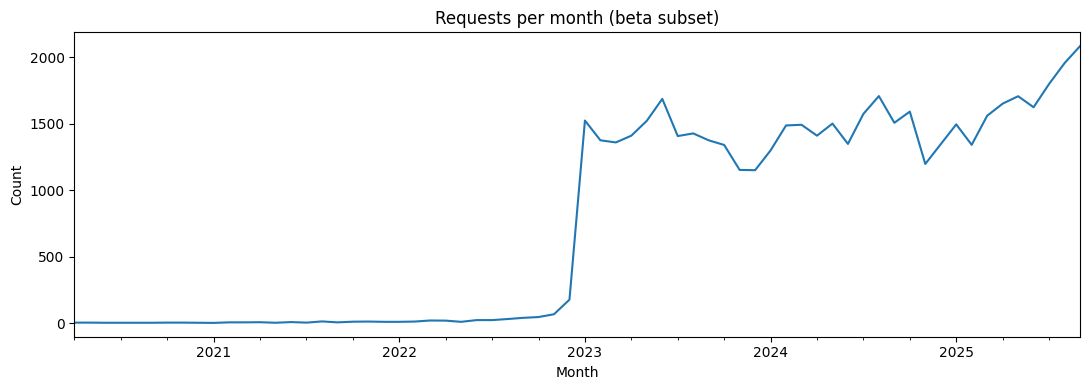

In [3]:
!pip install matplotlib
# Basic EDA on beta subset
import matplotlib.pyplot as plt

print(f"Shape: {beta_gdf.shape[0]:,} rows x {beta_gdf.shape[1]} columns")
print(f"CRS: {beta_gdf.crs}")

display(beta_gdf.dtypes.rename("dtype").to_frame())

missing_pct = (beta_gdf.isna().mean() * 100).sort_values(ascending=False).round(2)
display(missing_pct.to_frame("% missing").head(15))

if "geometry" in beta_gdf.columns:
    print("Geometry types:")
    display(beta_gdf.geometry.geom_type.value_counts(dropna=False).to_frame("count"))

for col in ["CategoryLevel1", "CategoryLevel2", "CategoryName", "CouncilDistrictNumber", "Neighborhood"]:
    if col in beta_gdf.columns:
        print(f"Top values for {col}:")
        display(beta_gdf[col].value_counts(dropna=False).head(10).to_frame("count"))

if "DateCreated" in beta_gdf.columns:
    dt = pd.to_datetime(beta_gdf["DateCreated"], errors="coerce", utc=True)
    print(f"DateCreated range: {dt.min()} to {dt.max()}")
    monthly_counts = dt.dt.to_period("M").value_counts().sort_index()
    ax = monthly_counts.plot(figsize=(11, 4), title="Requests per month (beta subset)")
    ax.set_xlabel("Month")
    ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()


## Step 4: Vacancy Signal Review
Inspect CategoryLevel2 and CategoryName values to identify vacancy-related complaint signals.


In [4]:
# Evaluate distinct CategoryLevel2 / CategoryName values for vacant-property relevance
import re
import pandas as pd

cat2_counts = beta_gdf['CategoryLevel2'].fillna('').astype(str).value_counts()
name_counts = beta_gdf['CategoryName'].fillna('').astype(str).value_counts()

high_patterns = [
    r'\bhousing\s*-\s*boardup\b',
    r'\bhousing\s*-\s*complaint\b',
    r'\bboard\s*up\b',
    r'\babandoned\b',
    r'\bvacan[tc]\b',
]

medium_patterns = [
    r'\bvehicle\s+off\s+street\b',
    r'\bwork\s+without\s+a\s+permit\b',
    r'\bjunk\b',
    r'\bdebris\b',
    r'\bgraffiti\b',
    r'\billegal\s+dumping\b',
    r'\bweeds\b',
    r'\bprivate\s+property\b',
    r'\bauto\s+repair\b',
    r'\bzoning\b',
    r'\bfences\b',
]

low_patterns = [
    r'\bnoise\s+complaint\b',
    r'\blandscaping\b',
    r'\boccupied\s+vehicle\b',
]

def vacancy_signal(text):
    t = str(text).lower().strip()
    if not t:
        return None
    for pat in high_patterns:
        if re.search(pat, t):
            return 'high'
    for pat in medium_patterns:
        if re.search(pat, t):
            return 'medium'
    for pat in low_patterns:
        if re.search(pat, t):
            return 'low'
    return None

rows = []
for value, count in cat2_counts.items():
    s = vacancy_signal(value)
    if s:
        rows.append({'field': 'CategoryLevel2', 'value': value, 'count': int(count), 'vacancy_signal': s})
for value, count in name_counts.items():
    s = vacancy_signal(value)
    if s:
        rows.append({'field': 'CategoryName', 'value': value, 'count': int(count), 'vacancy_signal': s})

vacancy_candidates = pd.DataFrame(rows).sort_values(['vacancy_signal', 'count'], ascending=[True, False])
print(f'Distinct CategoryLevel2: {cat2_counts.shape[0]}')
print(f'Distinct CategoryName: {name_counts.shape[0]}')
print(f'Distinct candidate entries flagged: {vacancy_candidates.shape[0]}')
display(vacancy_candidates.head(100))

c2_signal = beta_gdf['CategoryLevel2'].fillna('').astype(str).map(vacancy_signal)
cn_signal = beta_gdf['CategoryName'].fillna('').astype(str).map(vacancy_signal)

record_signal = pd.Series('none', index=beta_gdf.index, name='signal')
record_signal[(c2_signal == 'low') | (cn_signal == 'low')] = 'low'
record_signal[(c2_signal == 'medium') | (cn_signal == 'medium')] = 'medium'
record_signal[(c2_signal == 'high') | (cn_signal == 'high')] = 'high'

print('Record-level vacancy signal distribution:')
display(record_signal.value_counts().to_frame('count'))
display((record_signal.value_counts(normalize=True).mul(100).round(2)).to_frame('percent'))


Distinct CategoryLevel2: 210
Distinct CategoryName: 242
Distinct candidate entries flagged: 47


,field,value,count,vacancy_signal
5,CategoryLevel2,Housing - Complaint,156,high
27,CategoryName,Code Enforcement Housing - Complaint,156,high
10,CategoryLevel2,Housing - Boardup,47,high
33,CategoryName,Code Enforcement Housing - Boardup,47,high
16,CategoryLevel2,Abandoned,26,high
40,CategoryName,Animal Control Abandoned,26,high
1,CategoryLevel2,Occupied Vehicle,303,low
2,CategoryLevel2,Landscaping,284,low
23,CategoryName,Code Enforcement Landscaping,284,low
24,CategoryName,Homeless Camp Occupied Vehicle,199,low


Record-level vacancy signal distribution:


,count
signal,
none,47258
medium,1863
low,650
high,229


,percent
signal,
none,94.52
medium,3.73
low,1.30
high,0.46


## Step 5: Folium Renderer Helper
Define a reusable function to reliably render Folium maps in this environment.


In [5]:
# Reusable Folium renderer for environments that block trusted inline notebook JS
from pathlib import Path
from IPython.display import IFrame, display
import functools
import http.server
import socket
import socketserver
import threading
import webbrowser

_FOLIUM_SERVER = globals().get('_FOLIUM_SERVER', None)

def _start_folium_server(root_dir: Path):
    global _FOLIUM_SERVER
    if _FOLIUM_SERVER is not None:
        return _FOLIUM_SERVER

    handler = functools.partial(http.server.SimpleHTTPRequestHandler, directory=str(root_dir))
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(('127.0.0.1', 0))
        port = s.getsockname()[1]

    server = socketserver.ThreadingTCPServer(('127.0.0.1', port), handler)
    server.daemon_threads = True
    thread = threading.Thread(target=server.serve_forever, daemon=True)
    thread.start()

    _FOLIUM_SERVER = {'server': server, 'thread': thread, 'port': port, 'root': root_dir}
    return _FOLIUM_SERVER

def render_folium_map(map_obj, output_path, width='100%', height=700, prefer_localhost=True, open_browser=False):
    output_path = Path(output_path).resolve()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    map_obj.save(str(output_path))

    url = output_path.as_uri()
    if prefer_localhost:
        root = output_path.parents[1] if output_path.parent.name == 'outputs' else output_path.parent
        srv = _start_folium_server(root)
        rel = output_path.relative_to(root).as_posix()
        url = f"http://127.0.0.1:{srv['port']}/{rel}"

    display(IFrame(src=url, width=width, height=height))
    if open_browser:
        webbrowser.open(url)

    return output_path, url


## Step 6: Full Data Load and Joins
Load the full dataset, perform key cleaning, and join council district and parcel attributes.


In [6]:
# Vacancy workflow setup: full dataset load, Council District + parcel enrichment, with checkpoint fast-path
import subprocess
import sys
import re
from pathlib import Path
from time import perf_counter

def ensure_package(pkg_name):
    try:
        __import__(pkg_name)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg_name])

for pkg in ['folium', 'matplotlib', 'scipy', 'requests', 'statsmodels', 'gdown']:
    ensure_package(pkg)

import numpy as np
import requests
import gdown
import folium
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chisquare

base_dir = Path('hackathon_data') if Path('hackathon_data').exists() else Path('.')
full_data_path = base_dir / '311_data.gpkg'
outputs_dir = base_dir / '311_analysis_outputs'
outputs_dir.mkdir(parents=True, exist_ok=True)

# Step 6 checkpoint controls
step6_checkpoint_path = outputs_dir / 'step6_full_joined_checkpoint.gpkg'
force_rebuild_step6 = False  # set True to force full rebuild
required_checkpoint_cols = [
    'council_district', 'council_district_clean',
    'parcel_records', 'parcel_use_category', 'parcel_use_desc', 'parcel_use_categories'
]
debug_step6 = True  # set False for quieter logs

# ---------- Fast path: load checkpoint ----------
if step6_checkpoint_path.exists() and not force_rebuild_step6:
    gdf_full = gpd.read_file(step6_checkpoint_path, engine='pyogrio')
    missing_cols = [c for c in required_checkpoint_cols if c not in gdf_full.columns]
    if not missing_cols:
        print(f'Loaded Step 6 checkpoint: {step6_checkpoint_path} ({len(gdf_full):,} rows)')
    else:
        print(f'Checkpoint missing columns {missing_cols}; rebuilding from raw sources...')
        force_rebuild_step6 = True

# ---------- Rebuild path: run expensive joins once, then save checkpoint ----------
if force_rebuild_step6 or 'gdf_full' not in globals() or any(c not in gdf_full.columns for c in required_checkpoint_cols):
    t = {}

    full_cols = ['CategoryLevel1', 'CategoryLevel2', 'CategoryName', 'DateCreated', 'Neighborhood', 'ZIP', 'Address', 'CrossStreet', 'geometry']
    t0 = perf_counter()
    gdf_full = gpd.read_file(full_data_path, engine='pyogrio', columns=full_cols)
    t['full 311 read'] = perf_counter() - t0
    print(f'Loaded full dataset: {len(gdf_full):,} rows from {full_data_path}')

    if 'attach_assembly_districts' not in globals() or 'assembly_districts_gdf' not in globals():
        raise RuntimeError('Council District data/join function not loaded. Run the setup cell that imports district data.')

    t0 = perf_counter()
    gdf_full = attach_assembly_districts(gdf_full, assembly_districts_gdf)
    t['council district spatial attach'] = perf_counter() - t0

    if 'assembly_district' not in gdf_full.columns:
        raise RuntimeError('Council District join failed: missing assembly_district column from helper.')

    gdf_full['council_district'] = gdf_full['assembly_district']
    gdf_full['council_district_clean'] = gdf_full['council_district'].astype('string').fillna('Unknown').astype(str)

    valid_geom = gdf_full['geometry'].notna()
    null_count = int(gdf_full.loc[valid_geom, 'council_district_clean'].eq('Unknown').sum())
    valid_count = int(valid_geom.sum())
    matched_count = valid_count - null_count
    print(f'Council District join matched {matched_count:,}/{valid_count:,} rows with geometry ({(matched_count/valid_count*100 if valid_count else 0):.2f}%).')
    if matched_count == 0:
        raise RuntimeError('Council District join produced zero matches. Verify CRS and district geometry.')

    # Parcel data (Drive) and TABULAR address-key join (non-spatial)
    PARCEL_URL = 'https://drive.google.com/file/d/15vgX5iyJkzNJwr40z9Zi1c9kMNII_LUP/view?usp=drive_link'
    parcel_dir = base_dir / 'reference_data' / 'parcels'
    parcel_dir.mkdir(parents=True, exist_ok=True)
    parcel_path = parcel_dir / 'parcel_data'

    t0 = perf_counter()
    if not parcel_path.exists():
        m = re.search(r'/d/([A-Za-z0-9_-]+)', PARCEL_URL)
        if not m:
            raise ValueError('Could not parse parcel file id from URL')
        gdown.download(id=m.group(1), output=str(parcel_path), quiet=False, fuzzy=True)
    else:
        print(f'Using existing parcel file: {parcel_path}')
    t['parcel file locate/download'] = perf_counter() - t0

    try:
        import pyogrio
        parcel_info = pyogrio.read_info(parcel_path)
        parcel_fields = list(parcel_info.get('fields', []))
    except Exception:
        parcel_fields = []

    if not parcel_fields:
        _tmp = gpd.read_file(parcel_path, engine='pyogrio', rows=slice(0, 1))
        parcel_fields = [c for c in _tmp.columns if c != 'geometry']

    use_desc_col = 'USE_CODE_MINI_DESC' if 'USE_CODE_MINI_DESC' in parcel_fields else ('USE_CODE_MUNI_DESC' if 'USE_CODE_MUNI_DESC' in parcel_fields else None)
    if use_desc_col is None:
        raise RuntimeError('Parcel file missing USE_CODE_MINI_DESC/USE_CODE_MUNI_DESC field.')
    if 'SITE_ADDR' not in parcel_fields:
        raise RuntimeError('Parcel file missing SITE_ADDR field required for address join.')

    parcel_cols = ['SITE_ADDR', use_desc_col]
    t0 = perf_counter()
    try:
        parcels_df = pyogrio.read_dataframe(parcel_path, columns=parcel_cols, read_geometry=False)
    except Exception:
        parcels_df = gpd.read_file(parcel_path, engine='pyogrio', columns=parcel_cols)
        if 'geometry' in parcels_df.columns:
            parcels_df = pd.DataFrame(parcels_df.drop(columns='geometry'))
    if 'geometry' in parcels_df.columns:
        parcels_df = parcels_df.drop(columns='geometry')
    t['parcel attribute read (non-spatial)'] = perf_counter() - t0

    def normalize_addr_series(s):
        s = s.fillna('').astype(str).str.upper().str.strip()
        s = s.str.split(',').str[0]
        s = s.str.replace(r'[^A-Z0-9 ]', ' ', regex=True)
        s = s.str.replace(r'\s+', ' ', regex=True).str.strip()
        s = s.str.replace(r'^(APT|UNIT|STE)\s+\w+\s+', '', regex=True)
        return s

    def parcel_use_category(desc):
        d = str(desc or '').upper()
        if d == '':
            return 'Unknown'
        if any(k in d for k in ['VACANT', 'LOT', 'LAND', 'UNIMPROVED']):
            return 'Vacant Lot/Land'
        if any(k in d for k in ['SINGLE', 'DUPLEX', 'TRIPLEX', 'RESIDENT', 'APARTMENT', 'MOBILE HOME']):
            return 'Residential'
        if any(k in d for k in ['COMMERCIAL', 'RETAIL', 'OFFICE', 'STORE', 'HOTEL', 'MOTEL']):
            return 'Commercial'
        if any(k in d for k in ['INDUSTRIAL', 'WAREHOUSE', 'MANUFACTUR']):
            return 'Industrial'
        if any(k in d for k in ['PUBLIC', 'SCHOOL', 'PARK', 'RELIGIOUS', 'GOVERNMENT']):
            return 'Public/Institutional'
        return 'Other'

    t0 = perf_counter()
    parcels = parcels_df.copy()
    parcels['address_key'] = normalize_addr_series(parcels['SITE_ADDR'])
    parcels = parcels.loc[parcels['address_key'].ne('')].copy()
    parcels['parcel_use_desc'] = parcels[use_desc_col].astype('string').fillna('Unknown').str.strip()
    parcels.loc[parcels['parcel_use_desc'].eq(''), 'parcel_use_desc'] = 'Unknown'
    parcels['parcel_use_category'] = parcels['parcel_use_desc'].map(parcel_use_category).astype('string').fillna('Unknown')
    t['parcel normalize + category mapping'] = perf_counter() - t0

    t0 = perf_counter()
    parcel_records = parcels.groupby('address_key', as_index=False).size().rename(columns={'size': 'parcel_records'})
    cat_mode = (
        parcels.groupby(['address_key', 'parcel_use_category'], as_index=False)
        .size()
        .sort_values(['address_key', 'size', 'parcel_use_category'], ascending=[True, False, True])
        .drop_duplicates(subset=['address_key'])
        [['address_key', 'parcel_use_category']]
    )
    desc_mode = (
        parcels.groupby(['address_key', 'parcel_use_desc'], as_index=False)
        .size()
        .sort_values(['address_key', 'size', 'parcel_use_desc'], ascending=[True, False, True])
        .drop_duplicates(subset=['address_key'])
        [['address_key', 'parcel_use_desc']]
    )
    cat_set = (
        parcels.groupby('address_key', as_index=False)['parcel_use_category']
        .agg(lambda s: '; '.join(sorted(set(pd.Series(s).dropna().astype(str).str.strip()))))
        .rename(columns={'parcel_use_category': 'parcel_use_categories'})
    )
    parcel_agg = parcel_records.merge(cat_mode, on='address_key', how='left').merge(desc_mode, on='address_key', how='left').merge(cat_set, on='address_key', how='left')
    parcel_agg['parcel_use_category'] = parcel_agg['parcel_use_category'].fillna('Unknown')
    parcel_agg['parcel_use_desc'] = parcel_agg['parcel_use_desc'].fillna('Unknown')
    parcel_agg['parcel_use_categories'] = parcel_agg['parcel_use_categories'].fillna('Unknown')
    t['parcel aggregation by address_key'] = perf_counter() - t0

    t0 = perf_counter()
    gdf_full['address_key'] = normalize_addr_series(gdf_full['Address'])
    merge_cols = ['address_key', 'parcel_records', 'parcel_use_category', 'parcel_use_desc', 'parcel_use_categories']
    gdf_full = gdf_full.merge(parcel_agg[merge_cols], on='address_key', how='left', validate='m:1', suffixes=('_base', '_parcel'))

    for col in ['parcel_records', 'parcel_use_category', 'parcel_use_desc', 'parcel_use_categories']:
        if col not in gdf_full.columns:
            parcel_col = f'{col}_parcel'
            base_col = f'{col}_base'
            if parcel_col in gdf_full.columns and base_col in gdf_full.columns:
                gdf_full[col] = gdf_full[parcel_col].combine_first(gdf_full[base_col])
            elif parcel_col in gdf_full.columns:
                gdf_full[col] = gdf_full[parcel_col]
            elif base_col in gdf_full.columns:
                gdf_full[col] = gdf_full[base_col]
        for drop_col in [f'{col}_base', f'{col}_parcel']:
            if drop_col in gdf_full.columns:
                gdf_full = gdf_full.drop(columns=[drop_col])

    gdf_full['parcel_use_category'] = gdf_full.get('parcel_use_category', pd.Series(index=gdf_full.index, dtype='object')).fillna('Unknown')
    gdf_full['parcel_use_desc'] = gdf_full.get('parcel_use_desc', pd.Series(index=gdf_full.index, dtype='object')).fillna('Unknown')
    gdf_full['parcel_use_categories'] = gdf_full.get('parcel_use_categories', pd.Series(index=gdf_full.index, dtype='object')).fillna('Unknown')
    t['tabular merge gdf_full <- parcel_agg'] = perf_counter() - t0

    # Save checkpoint every rebuild
    gdf_full.to_file(step6_checkpoint_path, driver='GPKG')
    print(f'Saved Step 6 checkpoint: {step6_checkpoint_path}')

    if debug_step6:
        print('Step 6 timing summary (s):')
        for k, v in t.items():
            print(f'  - {k}: {v:.2f}')

join_matches = int(gdf_full['parcel_records'].notna().sum()) if 'parcel_records' in gdf_full.columns else 0
print(f'Parcel address join matched {join_matches:,}/{len(gdf_full):,} 311 records ({(join_matches/len(gdf_full)*100 if len(gdf_full) else 0):.2f}%).')
print('Parcel use categories in joined data (top 10):')
if 'parcel_use_category' in gdf_full.columns:
    display(gdf_full['parcel_use_category'].value_counts(dropna=False).head(10).to_frame('count'))
else:
    print('parcel_use_category not available in gdf_full.')


Loaded Step 6 checkpoint: hackathon_data\311_analysis_outputs\step6_full_joined_checkpoint.gpkg (1,545,157 rows)
Parcel address join matched 914,268/1,545,157 311 records (59.17%).
Parcel use categories in joined data (top 10):


,count
parcel_use_category,
Residential,727039
Unknown,630889
Other,76134
Commercial,44795
Public/Institutional,23778
Vacant Lot/Land,21297
Industrial,21225


## Step 7: Indicator Engineering
Filter likely vacancy records and create indicator labels/flags used in downstream analysis.


In [7]:
# Filter likely vacancy indicators and engineer indicator labels
gdf_full['DateCreated'] = pd.to_datetime(gdf_full['DateCreated'], errors='coerce', utc=True)
lvl1 = gdf_full['CategoryLevel1'].fillna('').astype(str)
lvl2 = gdf_full['CategoryLevel2'].fillna('').astype(str)
name = gdf_full['CategoryName'].fillna('').astype(str)

is_boardup = (lvl2 == 'Housing - Boardup') | (name == 'Code Enforcement Housing - Boardup')

# Exclude animal-control abandonment complaints from abandoned-property indicators.
is_animal_abandoned = (
    (name == 'Animal Control Abandoned')
    | ((lvl2 == 'Abandoned') & lvl1.str.contains('Animal Control', case=False, regex=False))
)
is_abandoned = (lvl2 == 'Abandoned') & (~is_animal_abandoned)

gdf_full['indicator_type'] = np.select(
    [is_boardup, is_abandoned],
    ['Board-up', 'Abandoned'],
    default='Other'
)
gdf_full['is_high_likelihood'] = gdf_full['indicator_type'].isin(['Board-up', 'Abandoned'])
vacant_df = gdf_full.loc[gdf_full['indicator_type'] != 'Other'].copy()
vacant_df['Neighborhood_clean'] = vacant_df['Neighborhood'].fillna('Unknown').astype(str).str.strip()
vacant_df.loc[vacant_df['Neighborhood_clean'] == '', 'Neighborhood_clean'] = 'Unknown'
vacant_df['ZIP_clean'] = vacant_df['ZIP'].fillna('').astype(str).str.extract(r'(\d{5})', expand=False).fillna('Unknown')
vacant_df['council_district_clean'] = vacant_df['council_district_clean'].fillna('Unknown')
vacant_df['parcel_use_category'] = vacant_df['parcel_use_category'].fillna('Unknown')
print(f'Filtered likely-indicator rows: {len(vacant_df):,}')
print('DateCreated range:', vacant_df['DateCreated'].min(), 'to', vacant_df['DateCreated'].max())
print('Missing geometry:', int(vacant_df.geometry.isna().sum()))
print('Missing ZIP:', int(vacant_df['ZIP_clean'].eq('Unknown').sum()))
print('Missing Council District:', int(vacant_df['council_district_clean'].eq('Unknown').sum()))
print('Missing Parcel Category:', int(vacant_df['parcel_use_category'].eq('Unknown').sum()))
print('Excluded animal-control abandoned complaints:', int(is_animal_abandoned.sum()))
print('\nIndicator type counts:')
display(vacant_df['indicator_type'].value_counts().to_frame('count'))
assert len(vacant_df) > 0, 'No rows matched likely indicator filter.'



Filtered likely-indicator rows: 919
DateCreated range: 2021-07-24 09:19:00+00:00 to 2025-09-29 07:17:00+00:00
Missing geometry: 0
Missing ZIP: 0
Missing Council District: 0
Missing Parcel Category: 233
Excluded animal-control abandoned complaints: 655

Indicator type counts:


,count
indicator_type,
Board-up,919


## Step 8: ZIP Choropleth Map
Build an interactive ZIP-level choropleth with indicator toggles and district metadata.


In [8]:
# Interactive Folium ZIP choropleth with toggle by indicator type + Council District metadata
ts_zip = vacant_df.loc[vacant_df['DateCreated'].notna(), ['ZIP_clean', 'DateCreated', 'indicator_type', 'council_district_clean']].copy()
ts_zip = ts_zip[ts_zip['ZIP_clean'].str.fullmatch(r'\d{5}')]
ts_zip['year'] = ts_zip['DateCreated'].dt.year.astype(int)
years = list(range(int(ts_zip['year'].min()), int(ts_zip['year'].max()) + 1))
zip_codes = sorted(ts_zip['ZIP_clean'].unique())

zcta_zip_path = outputs_dir / 'cb_2020_us_zcta520_500k.zip'
if not zcta_zip_path.exists():
    zcta_urls = [
        'https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_zcta520_500k.zip',
        'https://www2.census.gov/geo/tiger/GENZ2019/shp/cb_2019_us_zcta510_500k.zip',
    ]
    last_err = None
    for url in zcta_urls:
        try:
            r = requests.get(url, timeout=120)
            r.raise_for_status()
            zcta_zip_path.write_bytes(r.content)
            break
        except Exception as exc:
            last_err = exc
    if not zcta_zip_path.exists():
        raise RuntimeError(f'Unable to download ZIP polygons: {last_err}')

zcta = gpd.read_file(f'zip://{zcta_zip_path}')
zcta_col = 'ZCTA5CE20' if 'ZCTA5CE20' in zcta.columns else 'ZCTA5CE10'
zcta['ZIP_clean'] = zcta[zcta_col].astype(str).str.zfill(5)
zcta = zcta.loc[zcta['ZIP_clean'].isin(zip_codes)].copy()
if zcta.empty:
    raise RuntimeError('No Sacramento-area ZIP polygons matched the filtered 311 data.')

# ZIP-level Council District metadata
district_counts = ts_zip.groupby(['ZIP_clean', 'council_district_clean']).size().rename('n').reset_index()
dominant_district = (
    district_counts.sort_values(['ZIP_clean', 'n'], ascending=[True, False])
    .drop_duplicates(subset=['ZIP_clean'])
    .rename(columns={'council_district_clean': 'dominant_council_district', 'n': 'dominant_council_count'})
    [['ZIP_clean', 'dominant_council_district', 'dominant_council_count']]
)
district_unique = ts_zip.groupby('ZIP_clean')['council_district_clean'].nunique().rename('council_district_count').reset_index()
district_unknown = (
    ts_zip.assign(is_unknown=ts_zip['council_district_clean'].eq('Unknown').astype(int))
    .groupby('ZIP_clean')['is_unknown'].sum().rename('council_unknown_count').reset_index()
)
indicator_counts = ts_zip.groupby(['ZIP_clean', 'indicator_type']).size().unstack(fill_value=0).reset_index()

zip_tooltip_df = zcta[['ZIP_clean', 'geometry']].merge(dominant_district, on='ZIP_clean', how='left')
zip_tooltip_df = zip_tooltip_df.merge(district_unique, on='ZIP_clean', how='left')
zip_tooltip_df = zip_tooltip_df.merge(district_unknown, on='ZIP_clean', how='left')
zip_tooltip_df = zip_tooltip_df.merge(indicator_counts, on='ZIP_clean', how='left')
for c in ['Board-up', 'Abandoned']:
    if c not in zip_tooltip_df.columns:
        zip_tooltip_df[c] = 0
zip_tooltip_df[['Board-up', 'Abandoned']] = zip_tooltip_df[['Board-up', 'Abandoned']].fillna(0)
zip_tooltip_df['dominant_council_district'] = zip_tooltip_df['dominant_council_district'].fillna('Unknown')
zip_tooltip_df['dominant_council_count'] = zip_tooltip_df['dominant_council_count'].fillna(0)
zip_tooltip_df['council_district_count'] = zip_tooltip_df['council_district_count'].fillna(0)
zip_tooltip_df['council_unknown_count'] = zip_tooltip_df['council_unknown_count'].fillna(0)

if zcta.crs is None:
    zcta = zcta.set_crs('EPSG:4269')
zcta_wgs84 = zcta.to_crs('EPSG:4326')
zip_tooltip_wgs84 = zcta_wgs84[['ZIP_clean', 'geometry']].merge(zip_tooltip_df.drop(columns='geometry'), on='ZIP_clean', how='left')

sacramento_center = [38.5816, -121.4944]
m = folium.Map(location=sacramento_center, zoom_start=11, tiles='CartoDB positron')

def add_indicator_layer(layer_name, indicator_filter=None, show=False):
    if indicator_filter is None:
        layer_df = ts_zip.copy()
    else:
        layer_df = ts_zip.loc[ts_zip['indicator_type'] == indicator_filter].copy()

    if layer_df.empty:
        return

    zy = layer_df.groupby(['ZIP_clean', 'year']).size().rename('count').reset_index()
    full_idx = pd.MultiIndex.from_product([zip_codes, years], names=['ZIP_clean', 'year'])
    zy = zy.set_index(['ZIP_clean', 'year']).reindex(full_idx, fill_value=0).reset_index()
    zmetrics = zy.groupby('ZIP_clean', as_index=False)['count'].mean().rename(columns={'count': 'annual_avg_count'})
    zmetrics = zmetrics.merge(layer_df.groupby('ZIP_clean').size().rename('total_count').reset_index(), on='ZIP_clean', how='left')

    layer_polys = zcta_wgs84[['ZIP_clean', 'geometry']].merge(zmetrics, on='ZIP_clean', how='inner')
    if layer_polys.empty:
        return

    folium.Choropleth(
        geo_data=layer_polys.to_json(),
        data=layer_polys[['ZIP_clean', 'annual_avg_count']],
        columns=['ZIP_clean', 'annual_avg_count'],
        key_on='feature.properties.ZIP_clean',
        fill_color='YlOrRd',
        fill_opacity=0.7,
        line_opacity=0.25,
        legend_name=f'Annual average indicators: {layer_name}',
        nan_fill_color='lightgray',
        name=f'Indicator Layer: {layer_name}',
        show=show
    ).add_to(m)

add_indicator_layer('All Indicators', None, show=True)
add_indicator_layer('Board-up', 'Board-up', show=False)
add_indicator_layer('Abandoned', 'Abandoned', show=False)

tooltip = folium.features.GeoJsonTooltip(
    fields=['ZIP_clean', 'Board-up', 'Abandoned', 'dominant_council_district', 'dominant_council_count', 'council_district_count', 'council_unknown_count'],
    aliases=['ZIP:', 'Board-up count:', 'Abandoned count:', 'Dominant Council District:', 'Dominant District Count:', 'Distinct Districts in ZIP:', 'Unknown District Count:'],
    localize=True,
    sticky=True
)
folium.GeoJson(
    zip_tooltip_wgs84.to_json(),
    style_function=lambda _: {'fillOpacity': 0, 'weight': 0.5, 'color': '#555'},
    tooltip=tooltip,
    name='ZIP metadata'
).add_to(m)

if not zcta_wgs84.empty:
    minx, miny, maxx, maxy = zcta_wgs84.total_bounds
    m.fit_bounds([[miny, minx], [maxy, maxx]])

folium.LayerControl(collapsed=False).add_to(m)
zip_choropleth_html_path = outputs_dir / 'vacancy_zip_annual_avg_choropleth.html'
legacy_heatmap_html_path = outputs_dir / 'vacancy_heatmap_folium.html'
m.save(str(zip_choropleth_html_path))
m.save(str(legacy_heatmap_html_path))
print(f'Saved ZIP choropleth map with indicator toggles: {zip_choropleth_html_path}')
print(f'Updated legacy heatmap file: {legacy_heatmap_html_path}')
m


Saved ZIP choropleth map with indicator toggles: hackathon_data\311_analysis_outputs\vacancy_zip_annual_avg_choropleth.html
Updated legacy heatmap file: hackathon_data\311_analysis_outputs\vacancy_heatmap_folium.html


## Step 9: Time-Series Prep
Prepare monthly and aggregate tables used by temporal and summary visualizations.


In [9]:
# Time-series and aggregate prep
ts_df = vacant_df.loc[vacant_df['DateCreated'].notna()].copy()
ts_df['year'] = ts_df['DateCreated'].dt.year.astype(int)
ts_df['month_num'] = ts_df['DateCreated'].dt.month.astype(int)
zip_counts_all_time = ts_df.groupby('ZIP_clean').size().rename('count').reset_index()
zip_counts_all_time = zip_counts_all_time[zip_counts_all_time['ZIP_clean'].str.fullmatch(r'\d{5}|Unknown')]
zip_counts_all_time = zip_counts_all_time.sort_values('count', ascending=False).reset_index(drop=True)
month_counts = ts_df.groupby('month_num').size().reindex(range(1, 13), fill_value=0)
month_names = pd.Index(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
print('Years:', int(ts_df['year'].min()), 'to', int(ts_df['year'].max()))
print('Unique ZIP groups:', zip_counts_all_time.shape[0])


Years: 2021 to 2025
Unique ZIP groups: 22


## Step 10: Indicator Abundance Plot
Visualize overall counts of likely vacancy indicator types.


Saved indicator abundance barplot: hackathon_data\311_analysis_outputs\vacancy_indicator_abundance_all_dataset.png


,indicator_type,count
0,Board-up,919


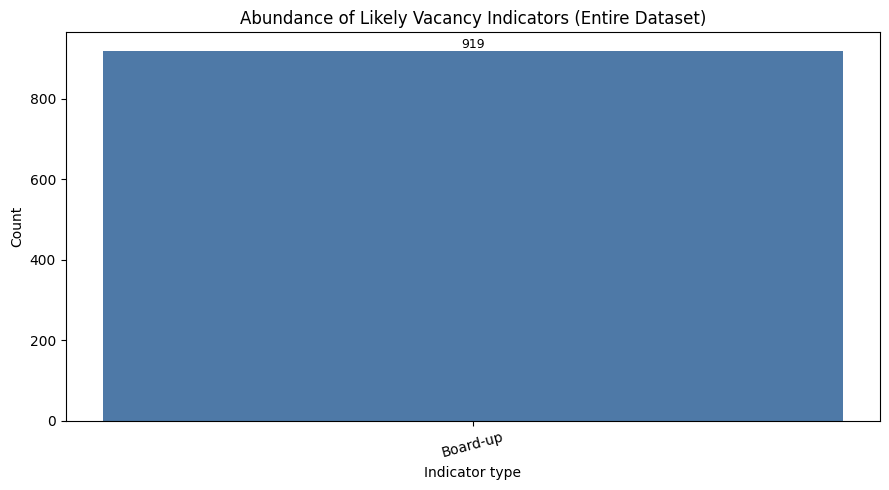

In [10]:
# Barplot: abundance of likely indicator types across the entire dataset
indicator_counts = vacant_df['indicator_type'].value_counts().rename_axis('indicator_type').reset_index(name='count')
indicator_counts = indicator_counts.sort_values('count', ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(indicator_counts['indicator_type'], indicator_counts['count'], color=['#4e79a7', '#f28e2b', '#e15759'])
ax.set_title('Abundance of Likely Vacancy Indicators (Entire Dataset)')
ax.set_xlabel('Indicator type')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(indicator_counts['count']):
    ax.text(i, v, f'{int(v):,}', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
indicator_barplot_path = outputs_dir / 'vacancy_indicator_abundance_all_dataset.png'
fig.savefig(indicator_barplot_path, dpi=150, bbox_inches='tight')
print(f'Saved indicator abundance barplot: {indicator_barplot_path}')
display(indicator_counts)
plt.show()


## Step 11: ZIP Ranking Plots
Generate ranked ZIP charts showing where likely vacancy indicators are most concentrated.


Saved ZIP ranked barplot (all): hackathon_data\311_analysis_outputs\vacancy_indicators_zip_rank_all.png


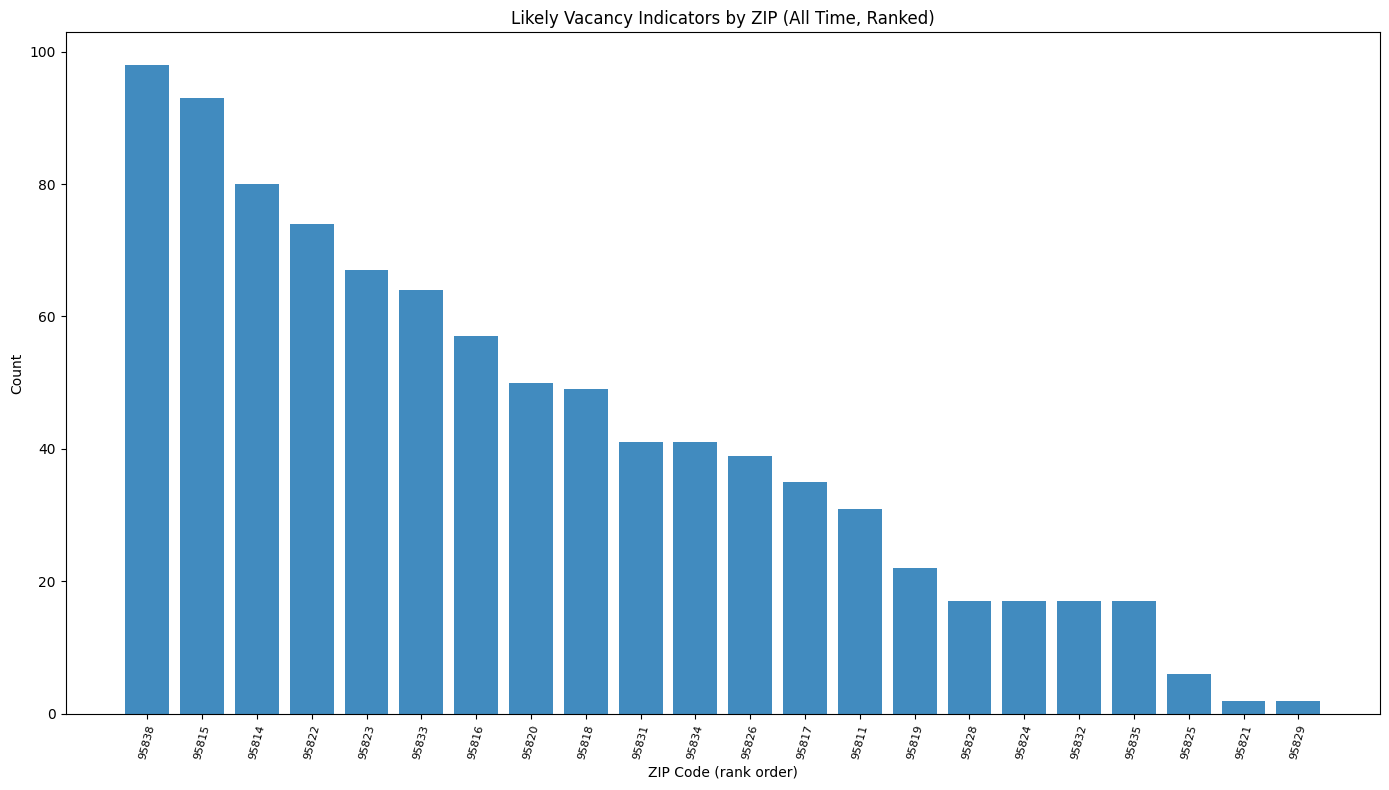

Saved ZIP ranked barplot (top): hackathon_data\311_analysis_outputs\vacancy_indicators_zip_rank_top15.png


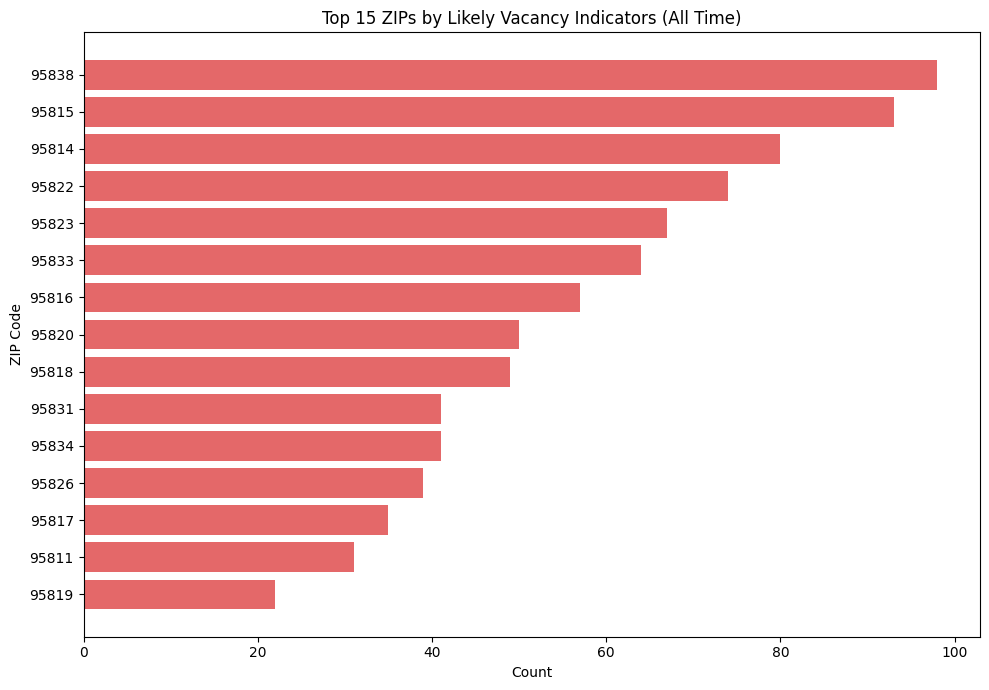

In [11]:
# Barplots: likely vacancy indicators by ZIP across all time (ranked high to low)
zip_rank = zip_counts_all_time.copy()
fig, ax = plt.subplots(figsize=(14, 8))
ax.bar(zip_rank['ZIP_clean'], zip_rank['count'], color='#1f77b4', alpha=0.85)
ax.set_title('Likely Vacancy Indicators by ZIP (All Time, Ranked)')
ax.set_xlabel('ZIP Code (rank order)')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=75, labelsize=8)
fig.tight_layout()
zip_barplot_all_path = outputs_dir / 'vacancy_indicators_zip_rank_all.png'
fig.savefig(zip_barplot_all_path, dpi=150, bbox_inches='tight')
print(f'Saved ZIP ranked barplot (all): {zip_barplot_all_path}')
plt.show()
top_n = min(15, len(zip_rank))
top_zip = zip_rank.head(top_n).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_zip['ZIP_clean'], top_zip['count'], color='#e15759', alpha=0.9)
ax.set_title(f'Top {top_n} ZIPs by Likely Vacancy Indicators (All Time)')
ax.set_xlabel('Count')
ax.set_ylabel('ZIP Code')
fig.tight_layout()
zip_barplot_top_path = outputs_dir / 'vacancy_indicators_zip_rank_top15.png'
fig.savefig(zip_barplot_top_path, dpi=150, bbox_inches='tight')
print(f'Saved ZIP ranked barplot (top): {zip_barplot_top_path}')
plt.show()


## Step 12: Seasonality Analysis
Evaluate monthly seasonality and identify periods with elevated indicator likelihood.


Chi-square test p-value (uniform month distribution): 1.42628e-05
Result: month-of-year distribution is statistically non-uniform (p < 0.05).
Top 5 months by likelihood (% of all indicators):


,month,count,probability
0,Jan,100,10.88
1,Feb,90,9.79
6,Jul,89,9.68
3,Apr,85,9.25
5,Jun,85,9.25


Saved seasonality plot: hackathon_data\311_analysis_outputs\vacancy_indicator_month_seasonality.png


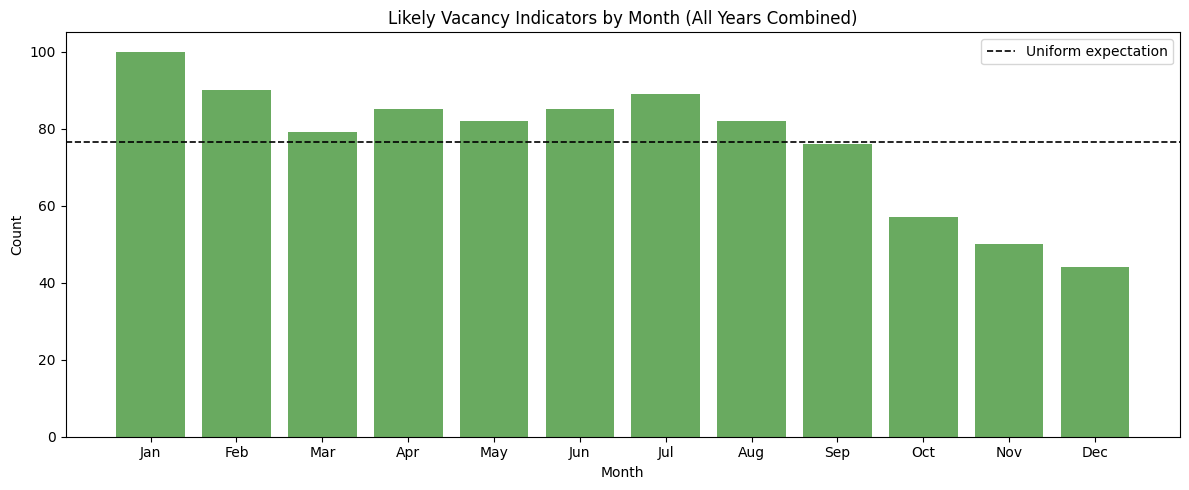

In [12]:
# Seasonality analysis: identify months with statistically higher likelihood
observed = month_counts.values.astype(float)
expected = [observed.sum() / 12.0] * 12
chi_res = chisquare(f_obs=observed, f_exp=expected)
month_prob = (month_counts / month_counts.sum()).rename('probability')
month_summary = pd.DataFrame({
    'month': month_names,
    'count': month_counts.values.astype(int),
    'probability': (month_prob.values * 100).round(2)
}).sort_values('probability', ascending=False)
print(f'Chi-square test p-value (uniform month distribution): {chi_res.pvalue:.6g}')
if chi_res.pvalue < 0.05:
    print('Result: month-of-year distribution is statistically non-uniform (p < 0.05).')
else:
    print('Result: no statistically significant month-of-year deviation from uniform at p < 0.05.')
print('Top 5 months by likelihood (% of all indicators):')
display(month_summary.head(5))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(month_names, month_counts.values, color='#59a14f', alpha=0.9)
ax.axhline(y=observed.sum()/12.0, color='black', linestyle='--', linewidth=1.2, label='Uniform expectation')
ax.set_title('Likely Vacancy Indicators by Month (All Years Combined)')
ax.set_xlabel('Month')
ax.set_ylabel('Count')
ax.legend()
fig.tight_layout()
seasonality_plot_path = outputs_dir / 'vacancy_indicator_month_seasonality.png'
fig.savefig(seasonality_plot_path, dpi=150, bbox_inches='tight')
print(f'Saved seasonality plot: {seasonality_plot_path}')
plt.show()


## Step 13: Street Hotspot Analysis
Find streets with the highest counts of high-likelihood vacancy indicators.


Saved street hotspot plot: hackathon_data\311_analysis_outputs\vacancy_high_likelihood_streets_top25.png


,street_key,count
0,BROADWAY,27
1,J ST,21
2,DEL PASO BLVD,20
3,FLORIN RD,17
4,O ST,16
5,FRANKLIN BLVD,16
6,FREEPORT BLVD,13
7,STOCKTON BLVD,13
8,L ST,12
9,FRUITRIDGE RD,12


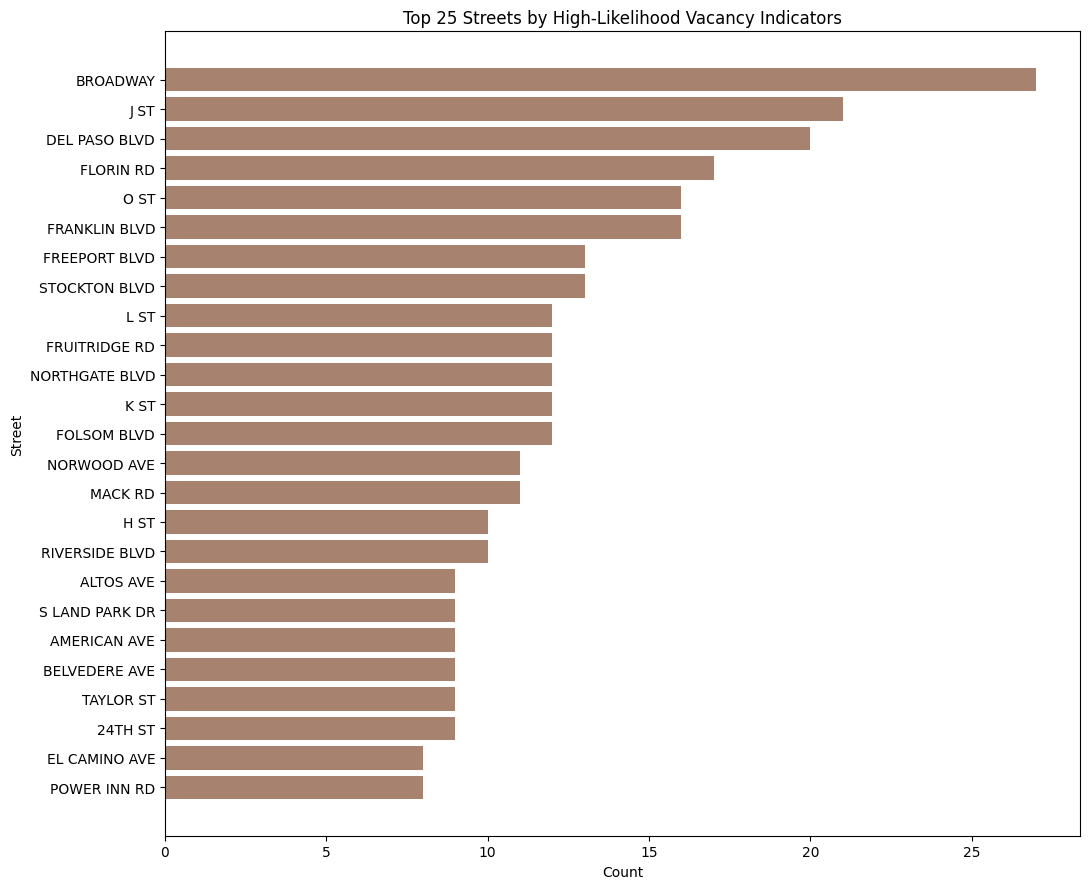

In [13]:
# Street-level analysis: high occurrence of high-likelihood vacancy indicators
high_df = vacant_df.loc[vacant_df['is_high_likelihood']].copy()
street_from_address = high_df['Address'].fillna('').astype(str).str.upper().str.split(',').str[0]
street_from_address = street_from_address.str.replace(r'^\s*\d+\s+', '', regex=True).str.strip()
street_from_cross = high_df['CrossStreet'].fillna('').astype(str).str.upper().str.strip()
high_df['street_key'] = street_from_address
high_df.loc[high_df['street_key'] == '', 'street_key'] = street_from_cross
high_df.loc[high_df['street_key'] == '', 'street_key'] = 'UNKNOWN'
street_counts = high_df.groupby('street_key').size().rename('count').sort_values(ascending=False).reset_index()
top_streets = street_counts.head(25).iloc[::-1]
fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(top_streets['street_key'], top_streets['count'], color='#9c755f', alpha=0.9)
ax.set_title('Top 25 Streets by High-Likelihood Vacancy Indicators')
ax.set_xlabel('Count')
ax.set_ylabel('Street')
fig.tight_layout()
street_plot_path = outputs_dir / 'vacancy_high_likelihood_streets_top25.png'
fig.savefig(street_plot_path, dpi=150, bbox_inches='tight')
print(f'Saved street hotspot plot: {street_plot_path}')
display(street_counts.head(25))
plt.show()


## Step 14: CategoryName-Abandoned Correlation
Compute and visualize correlations between CategoryName levels and the abandoned-property indicator before modeling.


<positron-console-cell-14>:102: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.


Saved CategoryName-Abandoned heatmap: hackathon_data\311_analysis_outputs\vacancy_categoryname_abandoned_correlation_heatmap.png
Saved CategoryName-Abandoned summary table: hackathon_data\311_analysis_outputs\vacancy_categoryname_abandoned_correlations.csv
Min count requested=20, used=20
Deterministic leakage categories excluded (Abandoned=1): None
Correlation fallback used because abandoned indicator had no/insufficient variance in leakage-filtered data.


,CategoryName,abandoned_rate,count
0,Animal Control 597 Animal Cruelty - Animal In ...,0.0,28
1,Animal Control 597 Animal Cruelty - Cruelty In...,0.0,44
2,Animal Control AC Customer Service,0.0,11435
3,Animal Control AC Customer Service - Adoption,0.0,45
4,Animal Control AC Customer Service - Investiga...,0.0,51
5,Animal Control AC Customer Service - License,0.0,184
6,Animal Control AC Customer Service - Other,0.0,1016
7,Animal Control AC Customer Service - Spay/Neuter,0.0,49
8,Animal Control Abandoned,0.0,654
9,Animal Control Animal Cruelty,0.0,595


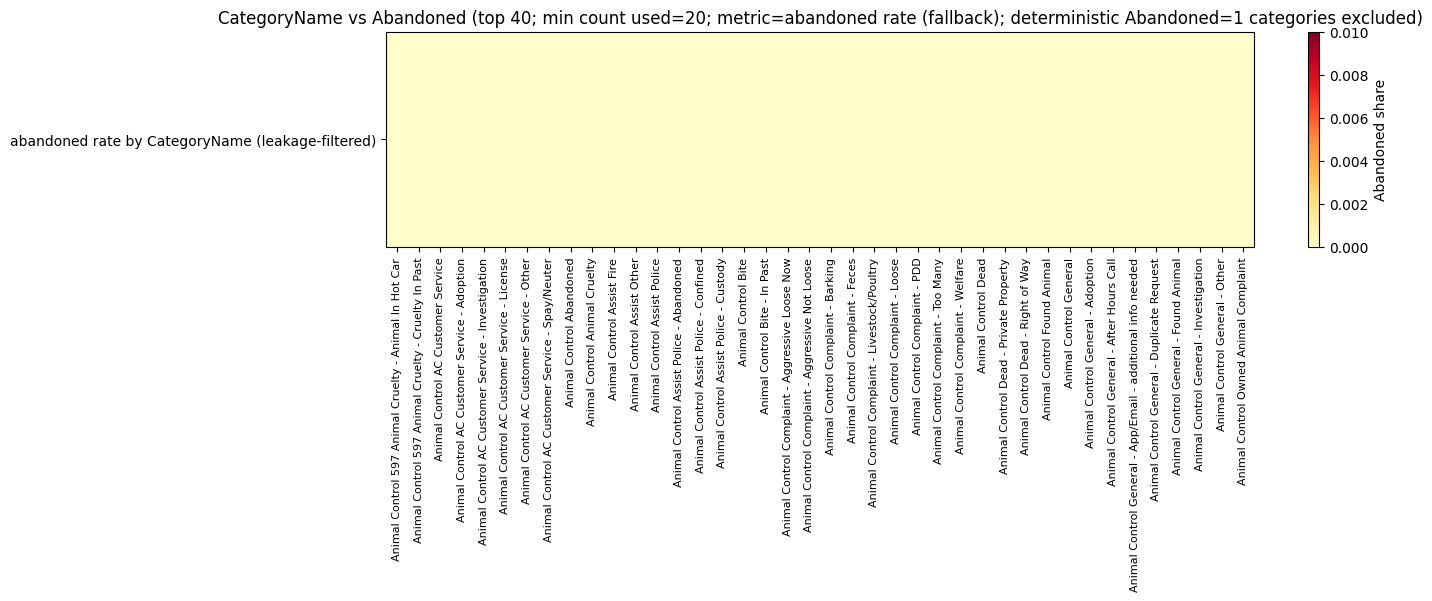

In [14]:
# Correlation heatmap: CategoryName levels vs abandoned-property indicator (before GLM)
corr_df = gdf_full.loc[gdf_full.geometry.notna(), ['CategoryName', 'indicator_type']].copy()
corr_df['CategoryName_clean'] = corr_df['CategoryName'].fillna('Unknown').astype(str)
corr_df['is_abandoned_int'] = corr_df['indicator_type'].eq('Abandoned').astype(int)

cat_counts_all = corr_df['CategoryName_clean'].value_counts()
requested_min_count = 20  # preferred stability threshold
candidate_thresholds = [requested_min_count, 10, 5, 1]

selected_min_count = None
corr_sub = pd.DataFrame()
for th in candidate_thresholds:
    kept_categories = cat_counts_all[cat_counts_all >= th].index
    trial = corr_df.loc[corr_df['CategoryName_clean'].isin(kept_categories)].copy()
    if len(trial) > 0:
        corr_sub = trial
        selected_min_count = th
        break

if selected_min_count is None or corr_sub.empty:
    raise RuntimeError('No rows available to compute CategoryName-Abandoned summary.')

# Leakage guard: remove CategoryName levels that deterministically encode Abandoned=1.
cat_rate = (
    corr_sub.groupby('CategoryName_clean', as_index=False)['is_abandoned_int']
    .agg(['mean', 'size'])
    .reset_index()
    .rename(columns={'CategoryName_clean': 'CategoryName', 'mean': 'abandoned_rate', 'size': 'count'})
)
leak_categories = cat_rate.loc[np.isclose(cat_rate['abandoned_rate'], 1.0), 'CategoryName'].tolist()

corr_work = corr_sub.loc[~corr_sub['CategoryName_clean'].isin(leak_categories)].copy()
if corr_work.empty:
    raise RuntimeError('All categories were deterministic leakage signals after filtering.')

cat_counts = corr_work['CategoryName_clean'].value_counts()
X = pd.get_dummies(corr_work['CategoryName_clean'], prefix='cat', drop_first=False)
y = corr_work['is_abandoned_int']

# If abandoned has no variation in subset, correlation is undefined; fall back to abandoned rate by category.
use_rate_fallback = (y.nunique() < 2)

if not use_rate_fallback:
    cat_corr = X.apply(lambda col: col.corr(y)).dropna()
else:
    cat_corr = pd.Series(dtype=float)

if len(cat_corr) > 0:
    metric_name = 'corr_with_abandoned'
    cat_metric_df = pd.DataFrame({
        'term': cat_corr.index,
        metric_name: cat_corr.values,
    })
    cat_metric_df['CategoryName'] = cat_metric_df['term'].str.replace(r'^cat_', '', regex=True)
    cat_metric_df['count'] = cat_metric_df['CategoryName'].map(cat_counts).astype(int)
    cat_metric_df = cat_metric_df[['CategoryName', metric_name, 'count']]
    cat_metric_df = cat_metric_df.sort_values(metric_name, key=np.abs, ascending=False)
    heat_label = 'corr (CategoryName dummy, Abandoned; leakage-filtered)'
    cmap = 'coolwarm'
else:
    metric_name = 'abandoned_rate'
    rate_df = (
        corr_work.groupby('CategoryName_clean', as_index=False)['is_abandoned_int']
        .agg(['mean', 'size'])
        .reset_index()
        .rename(columns={'CategoryName_clean': 'CategoryName', 'mean': metric_name, 'size': 'count'})
    )
    cat_metric_df = rate_df[['CategoryName', metric_name, 'count']].copy()
    cat_metric_df = cat_metric_df.sort_values(metric_name, ascending=False)
    heat_label = 'abandoned rate by CategoryName (leakage-filtered)'
    cmap = 'YlOrRd'

top_n = 40
plot_df = cat_metric_df.head(top_n).copy()
if plot_df.empty:
    raise RuntimeError('No CategoryName rows available for heatmap after leakage filtering.')

heat_vals = plot_df[metric_name].to_numpy()[None, :]
labels = plot_df['CategoryName'].tolist()

fig, ax = plt.subplots(figsize=(max(12, 0.35 * len(labels)), 2.8))
if metric_name == 'corr_with_abandoned':
    vmax = float(np.nanmax(np.abs(heat_vals))) if np.isfinite(heat_vals).all() else 1.0
    vmax = max(vmax, 0.05)
    im = ax.imshow(heat_vals, aspect='auto', cmap=cmap, vmin=-vmax, vmax=vmax)
else:
    vmax = float(np.nanmax(heat_vals)) if np.isfinite(heat_vals).all() else 1.0
    vmax = max(vmax, 0.01)
    im = ax.imshow(heat_vals, aspect='auto', cmap=cmap, vmin=0.0, vmax=vmax)

ax.set_yticks([0])
ax.set_yticklabels([heat_label])
ax.set_xticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_title(
    f'CategoryName vs Abandoned (top {len(labels)}; min count used={selected_min_count}; '
    + ('metric=correlation' if metric_name == 'corr_with_abandoned' else 'metric=abandoned rate (fallback)')
    + '; deterministic Abandoned=1 categories excluded)'
)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Pearson correlation' if metric_name == 'corr_with_abandoned' else 'Abandoned share')
fig.tight_layout()

cat_abandon_heatmap_path = outputs_dir / 'vacancy_categoryname_abandoned_correlation_heatmap.png'
cat_abandon_corr_csv_path = outputs_dir / 'vacancy_categoryname_abandoned_correlations.csv'
fig.savefig(cat_abandon_heatmap_path, dpi=150, bbox_inches='tight')
cat_metric_df.to_csv(cat_abandon_corr_csv_path, index=False)

print(f'Saved CategoryName-Abandoned heatmap: {cat_abandon_heatmap_path}')
print(f'Saved CategoryName-Abandoned summary table: {cat_abandon_corr_csv_path}')
print(f'Min count requested={requested_min_count}, used={selected_min_count}')
print(f'Deterministic leakage categories excluded (Abandoned=1): {leak_categories if leak_categories else "None"}')
if metric_name != 'corr_with_abandoned':
    print('Correlation fallback used because abandoned indicator had no/insufficient variance in leakage-filtered data.')
display(plot_df.head(20))
plt.show()



## Step 15: GLM (CategoryName Only)
Fit a binomial GLM predicting high-likelihood vacancy indicators using CategoryName predictors only.


In [15]:
# GLM: predictors of high-likelihood vacancy indicators using CategoryName only (with leakage guard)
point_df = gdf_full.loc[gdf_full.geometry.notna()].copy()
point_df['is_high_likelihood_int'] = point_df['is_high_likelihood'].astype(int)
point_df['CategoryName_clean'] = point_df['CategoryName'].fillna('Unknown').astype(str)

high_idx = point_df.index[point_df['is_high_likelihood_int'] == 1]
non_idx = point_df.index[point_df['is_high_likelihood_int'] == 0]
rng = np.random.default_rng(42)
non_sample_n = min(len(non_idx), max(2000, len(high_idx) * 2))
non_sample = rng.choice(non_idx.to_numpy(), size=non_sample_n, replace=False) if non_sample_n > 0 else np.array([], dtype=int)
focal_idx = np.concatenate([high_idx.to_numpy(), non_sample])
model_points = point_df.loc[focal_idx, ['is_high_likelihood_int', 'CategoryName_clean']].copy()

glm_df = model_points.reset_index(drop=True)

# Separation guard: drop deterministic CategoryName levels (all-0 or all-1 outcome within level).
cat_outcome = (
    glm_df.groupby('CategoryName_clean', as_index=False)['is_high_likelihood_int']
    .agg(['mean', 'size'])
    .reset_index()
    .rename(columns={'CategoryName_clean': 'CategoryName', 'mean': 'high_rate', 'size': 'count'})
)
non_deterministic_cats = cat_outcome.loc[(cat_outcome['high_rate'] > 0.0) & (cat_outcome['high_rate'] < 1.0), 'CategoryName'].tolist()
dropped_deterministic_cats = cat_outcome.loc[~cat_outcome['CategoryName'].isin(non_deterministic_cats), 'CategoryName'].tolist()

glm_work = glm_df.loc[glm_df['CategoryName_clean'].isin(non_deterministic_cats)].copy()

coef_df = pd.DataFrame(columns=['term', 'Coef.', 'Std.Err.', 'z', 'P>|z|', '[0.025', '0.975]', 'odds_ratio'])
glm_coef_path = outputs_dir / 'vacancy_glm_coefficients.csv'

if glm_work.empty or glm_work['is_high_likelihood_int'].nunique() < 2 or glm_work['CategoryName_clean'].nunique() < 2:
    print('GLM skipped: no non-deterministic CategoryName levels remain after leakage/separation guard.')
    print(f'Deterministic categories dropped: {len(dropped_deterministic_cats):,}')
    print(f'Kept non-deterministic categories: {len(non_deterministic_cats):,}')
    coef_df.to_csv(glm_coef_path, index=False)
else:
    formula = 'is_high_likelihood_int ~ C(CategoryName_clean)'
    glm_fit = smf.glm(formula=formula, data=glm_work, family=sm.families.Binomial()).fit()

    coef_df = glm_fit.summary2().tables[1].reset_index().rename(columns={'index': 'term'})
    coef_df['odds_ratio'] = np.exp(coef_df['Coef.'])
    coef_df = coef_df.sort_values('P>|z|')
    coef_df.to_csv(glm_coef_path, index=False)

    print('GLM converged:', glm_fit.converged)
    print(f'Focal points used after leakage guard: {len(glm_work):,} (high={glm_work["is_high_likelihood_int"].sum():,}, non-high={len(glm_work)-glm_work["is_high_likelihood_int"].sum():,})')
    print('Top significant terms (p < 0.05):')
    display(coef_df.loc[coef_df['P>|z|'] < 0.05, ['term','Coef.','odds_ratio','P>|z|']].head(25))

print(f'Deterministic categories dropped: {len(dropped_deterministic_cats):,}')
print(f'Kept non-deterministic categories: {len(non_deterministic_cats):,}')
print(f'Saved GLM coefficients: {glm_coef_path}')



GLM skipped: no non-deterministic CategoryName levels remain after leakage/separation guard.
Deterministic categories dropped: 138
Kept non-deterministic categories: 0
Deterministic categories dropped: 138
Kept non-deterministic categories: 0
Saved GLM coefficients: hackathon_data\311_analysis_outputs\vacancy_glm_coefficients.csv


## Step 16: Output Export and Validation
Write key outputs to disk and assert that required artifacts were generated successfully.


In [16]:
# Export filtered dataset and validate required outputs
vacancy_gpkg_path = outputs_dir / 'vacancy_filtered.gpkg'
vacancy_csv_path = outputs_dir / 'vacancy_filtered.csv'
vacant_df.to_file(vacancy_gpkg_path, driver='GPKG')
vacant_df.drop(columns='geometry').to_csv(vacancy_csv_path, index=False)
required_outputs = [
    zip_choropleth_html_path,
    legacy_heatmap_html_path,
    indicator_barplot_path,
    zip_barplot_all_path,
    zip_barplot_top_path,
    seasonality_plot_path,
    street_plot_path,
    cat_abandon_heatmap_path,
    cat_abandon_corr_csv_path,
    glm_coef_path,
    vacancy_gpkg_path,
    vacancy_csv_path,
]
for out_path in required_outputs:
    assert out_path.exists() and out_path.stat().st_size > 0, f'Output missing or empty: {out_path}'
print('Saved outputs:')
for out_path in required_outputs:
    print('-', out_path)


Saved outputs:
- hackathon_data\311_analysis_outputs\vacancy_zip_annual_avg_choropleth.html
- hackathon_data\311_analysis_outputs\vacancy_heatmap_folium.html
- hackathon_data\311_analysis_outputs\vacancy_indicator_abundance_all_dataset.png
- hackathon_data\311_analysis_outputs\vacancy_indicators_zip_rank_all.png
- hackathon_data\311_analysis_outputs\vacancy_indicators_zip_rank_top15.png
- hackathon_data\311_analysis_outputs\vacancy_indicator_month_seasonality.png
- hackathon_data\311_analysis_outputs\vacancy_high_likelihood_streets_top25.png
- hackathon_data\311_analysis_outputs\vacancy_categoryname_abandoned_correlation_heatmap.png
- hackathon_data\311_analysis_outputs\vacancy_categoryname_abandoned_correlations.csv
- hackathon_data\311_analysis_outputs\vacancy_glm_coefficients.csv
- hackathon_data\311_analysis_outputs\vacancy_filtered.gpkg
- hackathon_data\311_analysis_outputs\vacancy_filtered.csv


## Step 17: GLM Interpretation Report
Generate markdown text summarizing significant GLM terms and practical interpretation.


In [17]:
# Markdown interpretation of GLM output
from IPython.display import Markdown, display

sig = coef_df.loc[(coef_df['P>|z|'] < 0.05) & (coef_df['term'] != 'Intercept')].copy()
sig = sig.sort_values('P>|z|')
top_pos = sig.loc[sig['Coef.'] > 0].head(5)
top_neg = sig.loc[sig['Coef.'] < 0].head(5)

lines = []
lines.append('# GLM Interpretation (CategoryName-Only Model)')
lines.append('')
lines.append(f'- **Model**: Binomial GLM predicting whether a complaint is a high-likelihood vacancy indicator (Board-up or Abandoned).')
lines.append(f'- **Sample size**: {len(glm_df):,} focal points (high={int(glm_df["is_high_likelihood_int"].sum()):,}, non-high={int((glm_df["is_high_likelihood_int"]==0).sum()):,}).')
lines.append(f'- **Convergence**: {glm_fit.converged}.')
lines.append('')
lines.append('## Significant Positive Associations (higher odds)')
if len(top_pos) == 0:
    lines.append('- None at p < 0.05 in current specification.')
else:
    for _, r in top_pos.iterrows():
        lines.append(f'- `{r["term"]}`: coef={r["Coef."]:.3f}, OR={r["odds_ratio"]:.3f}, p={r["P>|z|"]:.3g}')

lines.append('')
lines.append('## Significant Negative Associations (lower odds)')
if len(top_neg) == 0:
    lines.append('- None at p < 0.05 in current specification.')
else:
    for _, r in top_neg.iterrows():
        lines.append(f'- `{r["term"]}`: coef={r["Coef."]:.3f}, OR={r["odds_ratio"]:.3f}, p={r["P>|z|"]:.3g}')

lines.append('')
lines.append('## Practical Read')
lines.append('- `CategoryName` is the only predictor family in this specification (modeled as categorical fixed effects).')
lines.append('- Significant terms indicate which complaint categories are associated with higher or lower odds relative to the baseline category.')
lines.append('- These are **associations/correlations**, not causal effects.')

md_text = '\n'.join(lines)
display(Markdown(md_text))
glm_md_path = outputs_dir / 'vacancy_glm_interpretation.md'
glm_md_path.write_text(md_text, encoding='utf-8')
print(f'Saved GLM interpretation markdown: {glm_md_path}')


NameError: name 'glm_fit' is not defined

## Step 18: Abandoned + Blight Map
Create an interactive map combining abandoned-property points with a blight-complaint heatmap.


In [ ]:
# Interactive map (Folium): abandoned-property red triangles + optional blight heatmap
from folium.plugins import HeatMap

# Derive abandoned directly from gdf_full to avoid stale notebook-state dependencies
lvl2_all = gdf_full['CategoryLevel2'].fillna('')
name_all = gdf_full['CategoryName'].fillna('')
abandoned_mask = (lvl2_all == 'Abandoned')
abandoned_pts = gdf_full.loc[abandoned_mask & gdf_full.geometry.notna()].copy()

# Ensure expected display columns exist for popup
if 'ZIP_clean' not in abandoned_pts.columns and 'ZIP' in abandoned_pts.columns:
    abandoned_pts['ZIP_clean'] = abandoned_pts['ZIP'].fillna('').astype(str).str.extract(r'(\d{5})', expand=False).fillna('Unknown')
if 'council_district_clean' not in abandoned_pts.columns and 'council_district' in abandoned_pts.columns:
    abandoned_pts['council_district_clean'] = abandoned_pts['council_district'].astype('string').fillna('Unknown').astype(str)
if 'parcel_use_category' not in abandoned_pts.columns:
    abandoned_pts['parcel_use_category'] = 'Unknown'
if 'parcel_use_desc' not in abandoned_pts.columns:
    abandoned_pts['parcel_use_desc'] = 'Unknown'

if abandoned_pts.crs is None:
    abandoned_pts = abandoned_pts.set_crs('EPSG:3857')
abandoned_pts = abandoned_pts.to_crs('EPSG:4326')
abandoned_pts['parcel_use_category_clean'] = abandoned_pts['parcel_use_category'].fillna('Unknown').astype(str).str.strip()

blight_mask = (
    lvl2_all.isin(['Illegal Dumping', 'Junk & Debris', 'Graffiti', 'Housing - Complaint', 'Housing - Boardup'])
    | name_all.str.contains('Illegal Dumping|Junk & Debris|Graffiti|Housing - Complaint|Housing - Boardup', case=False, regex=True)
)
blight_pts = gdf_full.loc[blight_mask & gdf_full.geometry.notna()].copy()
if blight_pts.crs is None:
    blight_pts = blight_pts.set_crs('EPSG:3857')
blight_pts = blight_pts.to_crs('EPSG:4326')

print('Map input counts -> Abandoned points:', len(abandoned_pts), '| Blight points:', len(blight_pts))
if len(abandoned_pts) == 0:
    raise RuntimeError('No abandoned points found from gdf_full (CategoryLevel2 == "Abandoned"). Re-run Step 6 and indicator prep cells.')

if len(abandoned_pts) > 0:
    center_lat = abandoned_pts.geometry.y.mean()
    center_lon = abandoned_pts.geometry.x.mean()
elif len(blight_pts) > 0:
    center_lat = blight_pts.geometry.y.mean()
    center_lon = blight_pts.geometry.x.mean()
else:
    raise RuntimeError('No geometry available for abandoned/blight map.')

# Folium map tuned for responsiveness
m2 = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles='CartoDB positron')

# Helper to create popup HTML
def _popup_html(r):
    addr = str(r.get('Address', '') or '').strip()
    if addr == '':
        addr = str(r.get('CrossStreet', '') or '').strip()
    if addr == '':
        addr = f'POINT ({r.geometry.y:.5f}, {r.geometry.x:.5f})'
    return (
        f"<b>Indicator:</b> Abandoned<br>"
        f"<b>Address/Location:</b> {addr}<br>"
        f"<b>Date Created:</b> {r.get('DateCreated', '')}<br>"
        f"<b>ZIP:</b> {r.get('ZIP_clean', 'Unknown')}<br>"
        f"<b>Council District:</b> {r.get('council_district_clean', 'Unknown')}<br>"
        f"<b>Parcel Use Category:</b> {r.get('parcel_use_category', 'Unknown')}<br>"
        f"<b>Parcel Use (raw):</b> {r.get('parcel_use_desc', 'Unknown')}"
    )

# Abandoned points: ALL (shown by default) so map never looks empty.
# Use CircleMarker here because RegularPolygonMarker is not rendering reliably in exported Folium HTML.
fg_all = folium.FeatureGroup(name='Abandoned: All', show=True)
for _, r in abandoned_pts.iterrows():
    folium.CircleMarker(
        location=[r.geometry.y, r.geometry.x],
        radius=5,
        color='#8B0000',
        weight=1,
        fill=True,
        fill_color='#8B0000',
        fill_opacity=0.9,
        popup=folium.Popup(_popup_html(r), max_width=360)
    ).add_to(fg_all)
fg_all.add_to(m2)

# Requested filters
filter_categories = ['Residential', 'Commercial']
for cat in filter_categories:
    fg = folium.FeatureGroup(name=f'Abandoned: {cat}', show=False)
    cat_df = abandoned_pts.loc[abandoned_pts['parcel_use_category_clean'].str.upper() == cat.upper()]
    for _, r in cat_df.iterrows():
        folium.CircleMarker(
            location=[r.geometry.y, r.geometry.x],
            radius=5,
            color='#8B0000',
            weight=1,
            fill=True,
            fill_color='#8B0000',
            fill_opacity=0.9,
            popup=folium.Popup(_popup_html(r), max_width=360)
        ).add_to(fg)
    fg.add_to(m2)

# Blight heatmap: optional layer OFF by default for zoom responsiveness
max_blight_heatmap_points = 15000
if len(blight_pts) > max_blight_heatmap_points:
    blight_plot = blight_pts.sample(n=max_blight_heatmap_points, random_state=42)
else:
    blight_plot = blight_pts
blight_points = list(zip(blight_plot.geometry.y, blight_plot.geometry.x))
fg_blight = folium.FeatureGroup(name='Blight Indicators Heatmap', show=False)
HeatMap(
    blight_points,
    radius=9,
    blur=12,
    min_opacity=0.25,
    max_zoom=15
).add_to(fg_blight)
fg_blight.add_to(m2)

# Fit bounds to abandoned points when available
if len(abandoned_pts) > 0:
    m2.fit_bounds([
        [abandoned_pts.geometry.y.min(), abandoned_pts.geometry.x.min()],
        [abandoned_pts.geometry.y.max(), abandoned_pts.geometry.x.max()]
    ])

folium.LayerControl(collapsed=False).add_to(m2)

# Save HTML and also emit the map so refreshed output is visible inside the notebook.
legacy_outputs_dir = base_dir / 'outputs'
legacy_outputs_dir.mkdir(parents=True, exist_ok=True)
abandoned_blight_map_path = legacy_outputs_dir / 'abandoned_points_blight_heatmap.html'
m2.save(str(abandoned_blight_map_path))
print(f'Saved abandoned+blight map: {abandoned_blight_map_path}')

if outputs_dir != legacy_outputs_dir:
    alt_map_path = outputs_dir / 'abandoned_points_blight_heatmap.html'
    m2.save(str(alt_map_path))
    print(f'Saved abandoned+blight map (alt): {alt_map_path}')

res_n = int((abandoned_pts['parcel_use_category_clean'].str.upper() == 'RESIDENTIAL').sum())
com_n = int((abandoned_pts['parcel_use_category_clean'].str.upper() == 'COMMERCIAL').sum())
print('Abandoned points total:', len(abandoned_pts), '| Residential:', res_n, '| Commercial:', com_n)
print('Blight points total:', len(blight_pts), '| Blight points used in heatmap:', len(blight_plot))

m2


Map input counts -> Abandoned points: 654 | Blight points: 52256


Saved abandoned+blight map: hackathon_data\outputs\abandoned_points_blight_heatmap.html


Saved abandoned+blight map (alt): hackathon_data\311_analysis_outputs\abandoned_points_blight_heatmap.html
Abandoned points total: 654 | Residential: 339 | Commercial: 43
Blight points total: 52256 | Blight points used in heatmap: 15000
